In [19]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from natsort import natsorted

Data prep

In [20]:
data_bb=pd.read_csv('../dihedrals_medoids_new/dihedrals_medoids_new_bb.csv')
data_chi=pd.read_csv('../dihedrals_medoids_new/dihedrals_medoids_new_chi.csv')
data_time=pd.read_csv('../Database/Dataset_4f_time_only/clustering_results_4c_4f.csv')

BB - dih prep

In [21]:
data_bb=data_bb.drop(['cluster_id','rank', 'og_idx'],axis=1)
kol_kat_bb=[col for col in data_bb.columns if col not in ['top','seq','time','lay','copy']]
rad_bb=np.radians(data_bb[kol_kat_bb])
sin_bb=np.sin(rad_bb).add_suffix('_sin')
cos_bb=np.cos(rad_bb).add_suffix('_cos')
sin_cos_bb=pd.concat([data_bb[['top','seq']],sin_bb,cos_bb],axis=1)
#print(sin_cos_bb.head(15))

Chi - dih prep

In [22]:
data_chi=data_chi.drop(['cluster_id','rank'],axis=1)
kol_kat_chi=[col for col in data_chi.columns if col not in ['top','seq','time','lay','copy']]
kol_kat_chi=natsorted(kol_kat_chi)
rad_chi=np.radians(data_chi[kol_kat_chi])
sin_chi=np.sin(rad_chi).add_suffix('_sin')
cos_chi=np.cos(rad_chi).add_suffix('_cos')
sin_cos_chi=pd.concat([sin_chi,cos_chi],axis=1)
#print(sin_cos_chi.head(15))

DAta marge - final dataframe
Input to model = 306

In [25]:
data_fin=pd.concat([sin_cos_bb,sin_cos_chi],axis=1)
#print(data_fin.head(15))

Wyczyszczenie danych czasowych

In [27]:
data_time=data_time.drop(['stddevi','mediana_czas','max_czas','cluster_results_KMeans','cluster_results_KMedoids'],axis=1)
#print(data_time.head(15))

Łączenie dataframow aby mieć wszystko w jednym czas i wektor

In [28]:
data_fin=pd.merge(data_fin,data_time, on=['top','seq'], how='inner')
#data_fin['sredni_czas']=data_fin['sredni_czas']/1000  #podzielenie przez 1000 aby dosatać nanosekundy
data_fin=data_fin.fillna(0)
#print(data_fin.head(15))

Lets make model - tensor database

In [8]:
X_col=[col for col in data_fin.columns if col not in ['top','seq','sredni_czas']]
X_df=data_fin[X_col]
Y_df=data_fin['sredni_czas']
#podział na podzbiory
X_temp,X_test,Y_temp,Y_test=train_test_split(X_df,Y_df,test_size=0.15,random_state=10)
X_train,X_val,Y_train,Y_val=train_test_split(X_temp,Y_temp,test_size=0.176,random_state=10)
#tensory
X_tensor_train=torch.tensor(X_train.to_numpy(), dtype=torch.float)
Y_tensor_train=torch.tensor(Y_train.to_numpy(), dtype=torch.float)
X_tensor_test=torch.tensor(X_test.to_numpy(), dtype=torch.float)
Y_tensor_test=torch.tensor(Y_test.to_numpy(), dtype=torch.float)
X_tensor_val=torch.tensor(X_val.to_numpy(), dtype=torch.float)
Y_tensor_val=torch.tensor(Y_val.to_numpy(), dtype=torch.float)

# tensorowe sprawy
batch=100
train_dataset=TensorDataset(X_tensor_train,Y_tensor_train)
train_loader=DataLoader(train_dataset,batch_size=batch,shuffle=True)

Model making

In [9]:
class GQuadAngelsPred(nn.Module):
    def __init__(self):
        super(GQuadAngelsPred, self).__init__()
        # Neuron layers
        self.fc1=nn.Linear(306, 128)
        self.fc2=nn.Linear(128, 64)
        self.fc3=nn.Linear(64, 32)
        self.fc5=nn.Linear(32,16)
        self.fc6=nn.Linear(64,1)

        # Activation and drop function
        self.re=nn.ReLU()
        self.drop=nn.Dropout(p=0.20)
        self.batchnorm_128=nn.BatchNorm1d(128)


    def forward(self, x):
        x=self.re(self.fc1(x))
        #x=self.batchnorm_128(x)
        x=self.re(self.fc2(x))
        x=self.drop(x)
        #x=self.re(self.fc3(x))
        x=self.drop(x)
        #x=self.re(self.fc5(x))
        projection=self.fc6(x)
        return projection

model=GQuadAngelsPred()
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001, weight_decay=1.5e-3)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.85,
    patience=10,
    min_lr=7e-7,
)


epoche=10000
best_val_loss=float('inf')
how_many=80
counter_dd=0

for epoch in range(epoche):
    model.train()
    total_loss = 0

    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        prediction = model(batch_X)
        loss = criterion(prediction, batch_Y.view(-1,1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Fixed variable name
    avg_train_loss = total_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
        # Fixed variables to use the validation tensors
        val_predictions = model(X_tensor_val)
        val_loss = criterion(val_prledictions, Y_tensor_val.view(-1,1)).item()
        #scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter_dd = 0
    else:
        counter_dd += 1

    if epoch %10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
    if counter_dd >= how_many:
        print("Early Stopping")
        best_val_loss = np.sqrt(best_val_loss)
        #print(f'Średni błąd Validacji: {best_val_loss:.4f}')
        break

Epoch 000 | Train Loss: 224773407491.0118 | Val Loss: 227913793536.0000
Epoch 010 | Train Loss: 78245809838.6824 | Val Loss: 78185742336.0000
Epoch 020 | Train Loss: 70699671889.3176 | Val Loss: 71211704320.0000
Epoch 030 | Train Loss: 65244092006.4000 | Val Loss: 66383552512.0000
Epoch 040 | Train Loss: 63073786892.0471 | Val Loss: 64109416448.0000
Epoch 050 | Train Loss: 62025874058.5412 | Val Loss: 62601805824.0000
Epoch 060 | Train Loss: 60661430055.1529 | Val Loss: 61456203776.0000
Epoch 070 | Train Loss: 59781617447.1529 | Val Loss: 60595032064.0000
Epoch 080 | Train Loss: 59242010407.1529 | Val Loss: 59921780736.0000
Epoch 090 | Train Loss: 58555867184.1882 | Val Loss: 59384967168.0000
Epoch 100 | Train Loss: 57905981560.4706 | Val Loss: 59010686976.0000
Epoch 110 | Train Loss: 57389948638.8706 | Val Loss: 58654732288.0000
Epoch 120 | Train Loss: 56414287558.7765 | Val Loss: 58361765888.0000
Epoch 130 | Train Loss: 56666573113.2235 | Val Loss: 58130468864.0000
Epoch 140 | Train 

Testowanie modelu

--- FINAL EXAM RESULTS ---
On average, the model is off by: 171100.25 time units
R-squared Score (Accuracy proxy): 0.43


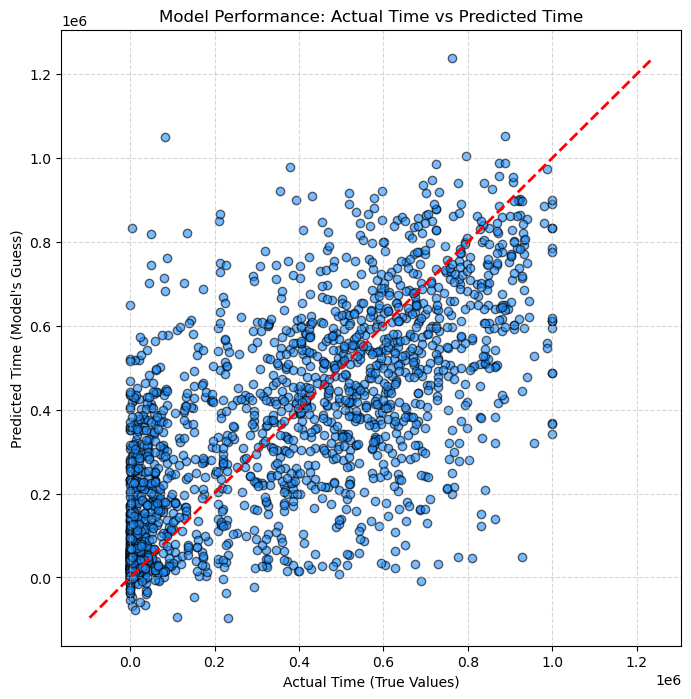

In [10]:
# 1. Put the model into evaluation mode (turns off training features)
model.eval()

# 2. Make predictions on the completely unseen TEST data
with torch.no_grad():
    test_predictions = model(X_tensor_test)

# 3. Convert PyTorch Tensors back to normal Numpy arrays
# (Matplotlib and Sklearn prefer normal arrays)
actuals = Y_tensor_test.numpy()
preds = test_predictions.numpy()

# if using np.log() data
#actuals = 10 ** actuals
#preds = 10 ** preds

# 4. Calculate "Human-Readable" Scores
# MAE (Mean Absolute Error): On average, how many units of time is the prediction wrong by?
mae = mean_absolute_error(actuals, preds)

# R2 Score: A percentage of how well the model fits the data (1.0 is perfect, 0.0 is terrible)
r2 = r2_score(actuals, preds)

print("--- FINAL EXAM RESULTS ---")
print(f"On average, the model is off by: {mae:.2f} time units")
print(f"R-squared Score (Accuracy proxy): {r2:.2f}")

# 5. Draw the "Actual vs. Predicted" Plot
plt.figure(figsize=(8, 8))
plt.scatter(actuals, preds, alpha=0.6, color='dodgerblue', edgecolors='k')

# Draw a red diagonal line. If the model is perfect, all blue dots will sit exactly on this red line.
min_val = min(actuals.min(), preds.min())
max_val = max(actuals.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

# Make the plot look nice
plt.title("Model Performance: Actual Time vs Predicted Time")
plt.xlabel("Actual Time (True Values)")
plt.ylabel("Predicted Time (Model's Guess)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [30]:
data_fin.to_csv('Database_fin_20n.csv', index=False)

In [29]:
print(data_fin.head())

      top  seq    b1_sin    g1_sin    d1_sin    e1_sin    z1_sin    a2_sin  \
0  -l-p-l  244 -0.791544  0.968060  0.580845 -0.119964 -0.993211 -0.918239   
1  -l-p-l  244 -0.458650  0.996478  0.669520 -0.102098 -0.976785 -0.924346   
2  -l-p-l  244 -0.765596  0.978148  0.626196 -0.266229 -0.968583 -0.947154   
3  -l-p-l  244 -0.777585  0.975955  0.645724 -0.218825 -0.998049 -0.924280   
4  -l-p-l  244 -0.270600  0.959658  0.612217 -0.389445 -0.946368 -0.996862   

     b2_sin    g2_sin  ...  DT10_cos  DT11_cos  DT12_cos  DT13_cos  DT14_cos  \
0  0.414534  0.814622  ... -0.624698       0.0       0.0 -0.998939 -0.840850   
1  0.241244  0.722243  ... -0.306692       0.0       0.0 -0.997224 -0.999973   
2  0.224781  0.798110  ... -0.720914       0.0       0.0 -0.974252 -0.568849   
3  0.220187  0.767613  ... -0.813811       0.0       0.0 -0.910900 -0.088894   
4  0.136061  0.854912  ... -0.181034       0.0       0.0 -0.796635 -0.999456   

   DT15_cos  DT16_cos  DT17_cos  DT18_cos    sredn

In [11]:
torch.save(model.state_dict(), '../modele - wytrenowane/model_dihedrals_good.pth')

In [12]:
print(data_bb)

          top  seq lay  copy     time      b1     g1      d1      e1      z1  \
0      -l-p-l  244  sa     3  63380.0 -127.67  75.48  144.49 -173.11  -83.32   
1      -l-p-l  244  sa     3  53880.0 -152.70  85.19  137.97 -174.14  -77.63   
2      -l-p-l  244  sa     3  72700.0 -130.04  78.00  141.23 -164.56  -75.60   
3      -l-p-l  244  sa     3  20180.0 -128.96  77.41  139.78 -167.36  -86.42   
4      -l-p-l  244  sa     3  53560.0 -164.30  73.67  142.25 -157.08  -71.15   
...       ...  ...  ..   ...      ...     ...    ...     ...     ...     ...   
25321   +pd-l  144  sa     1      0.0 -113.39  80.06  148.17 -163.50  -79.55   
25322   +pd-l  144  sa     2      0.0 -112.65  81.36  149.65 -163.26  -85.30   
25323    d-pd  142  sa     3      0.0 -149.11  74.15  139.81 -156.21  -29.11   
25324    d-pd  142  sa     2      0.0 -131.48  71.21   85.52 -127.30 -109.47   
25325    d-pd  142  sa     1      0.0 -127.72 -30.92  131.42 -157.63  -71.09   

       ...  b19  g19  d19  e19  z19  a2

In [24]:
print(kol_kat_chi)

['DG1', 'DG2', 'DG4', 'DG5', 'DG6', 'DG7', 'DG8', 'DG9', 'DG10', 'DG11', 'DG12', 'DG13', 'DG14', 'DG15', 'DG16', 'DG17', 'DG18', 'DG19', 'DG20', 'DT3', 'DT4', 'DT5', 'DT6', 'DT7', 'DT8', 'DT9', 'DT10', 'DT11', 'DT12', 'DT13', 'DT14', 'DT15', 'DT16', 'DT17', 'DT18']
